# 🚇 팀 B — 서울 지하철 분석 프로젝트
## Week 2: 심화 분석 — 호선 통계, 핫스팟 식별, 승하차 비대칭 (25점)

---

### 팀 정보 (Week 1과 동일하게 작성)

| 역할 | 이름 | 학번 | 이번 주 담당 |
|---|---|---|---|
| 분석가 A | _____ | _____ | _____ |
| 분석가 B | _____ | _____ | _____ |
| 시각화/디자인 C | _____ | _____ | _____ |

---

## 📖 이번 주 목표

Week 1에서 long format으로 변환한 데이터를 활용하여 **공간(역·호선) 차원 핫스팟**을 식별합니다.

1. 부가 정보 결합 (환승역 식별 등)
2. 호선별 종합 통계
3. 호선별 핵심 핫스팟 역 추출
4. **승차/하차 비대칭** 분석 (주거지 vs 업무지 분류)
5. 가설 본격 검증

**중요:** 코드의 구체적 작성 방식은 팀이 직접 결정하세요.

---

## ⚙️ 환경 설정 + 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

---
## Q1. Week 1 결과 불러오기 (2점)

**과제:**
- (a) Week 1에서 저장한 long format 데이터(`subway_clean.csv`)를 불러오기
- (b) 컬럼들이 그대로 살아있는지 확인 (`hour`, `type`, `time_period` 등)
- (c) 자료형 점검 (필요 시 datetime/integer 재변환)

**예상 결과:** Week 1 마지막 시점의 long format 데이터프레임

In [2]:
# (a)
subway = pd.read_csv('subway_clean.csv')

In [3]:
# (b)
subway.columns

Index(['month', 'line', 'station', 'variable', 'value', 'hour', 'type',
       'time_period'],
      dtype='object')

In [4]:
# (c)
subway.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29808 entries, 0 to 29807
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   month        29808 non-null  object
 1   line         29808 non-null  object
 2   station      29808 non-null  object
 3   variable     29808 non-null  object
 4   value        29808 non-null  int64 
 5   hour         29808 non-null  int64 
 6   type         29808 non-null  object
 7   time_period  29808 non-null  object
dtypes: int64(2), object(6)
memory usage: 1.8+ MB


---
## Q2. 환승역 정보 추가 (4점)

**과제:**
- (a) 같은 역명이 여러 호선에 존재하면 **환승역**입니다. 역명별 호선 개수를 세서 **`is_transfer`** (True/False) 또는 **`n_lines`** (정수) 컬럼을 데이터프레임에 추가
- (b) 환승역 개수, 일반역 개수 출력
- (c) 환승역 중 호선 3개 이상에 걸친 역 (예: 종로3가, 동대문역사문화공원 등) 의 이름과 호선 개수 출력

**예상 결과:**
- 서울 지하철에 환승역은 약 80여 개 (호선 2개 이상)
- 호선 3개 이상 환승역은 10여 개

In [5]:
# (a) 환승역 정보 추가
line_counts = subway.groupby('station')['line'].nunique()
subway['n_lines'] = subway['station'].map(line_counts)
subway['is_transfer'] = subway['n_lines'] >= 2
subway.head()

,month,line,station,variable,value,hour,type,time_period,n_lines,is_transfer
0,2026-04-01,1호선,동대문,04시-05시 승차인원,699,4,승차,night,2,True
1,2026-04-01,1호선,동묘앞,04시-05시 승차인원,203,4,승차,night,2,True
2,2026-04-01,1호선,서울역,04시-05시 승차인원,714,4,승차,night,5,True
3,2026-04-01,1호선,시청,04시-05시 승차인원,175,4,승차,night,2,True
4,2026-04-01,1호선,신설동,04시-05시 승차인원,484,4,승차,night,3,True


In [6]:
# (b) 환승역/일반역 개수

# station 기준으로 중복된 열 삭제
unique_stations = subway.drop_duplicates(subset=['station'])

# is_transfer True인걸 세면 환승역의 개수가 나온다
transfer_count = unique_stations['is_transfer'].sum()

# 전체 개수에서 환승역 수를 빼면 일반역 수
normal_count = len(unique_stations) - transfer_count

print(f"환승역 개수 : {transfer_count}개")
print(f"일반역 개수 : {normal_count}개")
unique_stations.head()

환승역 개수 : 77개
일반역 개수 : 452개


,month,line,station,variable,value,hour,type,time_period,n_lines,is_transfer
0,2026-04-01,1호선,동대문,04시-05시 승차인원,699,4,승차,night,2,True
1,2026-04-01,1호선,동묘앞,04시-05시 승차인원,203,4,승차,night,2,True
2,2026-04-01,1호선,서울역,04시-05시 승차인원,714,4,승차,night,5,True
3,2026-04-01,1호선,시청,04시-05시 승차인원,175,4,승차,night,2,True
4,2026-04-01,1호선,신설동,04시-05시 승차인원,484,4,승차,night,3,True


In [7]:
# (c) 호선 3개 이상 환승역
lines_f = (unique_stations['n_lines'] >= 3)
transfer_f = (unique_stations['is_transfer'] == True)
transfer_3 = unique_stations[lines_f & transfer_f][['station', 'n_lines']]

print(transfer_3)

            station  n_lines
2               서울역        5
4               신설동        3
7              종로3가        3
20   동대문역사문화공원(DDP)        3
45        왕십리(성동구청)        3
59             홍대입구        3
63            고속터미널        3
126              공덕        4
132            김포공항        5
185        디지털미디어시티        3


---
## Q3. 호선별 종합 통계 (4점)

**과제:**
- (a) 호선별로 다음 4가지 지표를 한 번에 가진 종합 통계표 만들기 (변수명 `line_summary`):
  - 호선 내 역 수
  - 호선 총 승차 인원
  - 호선 총 하차 인원
  - 호선 평균 승하차 인원 (역당)
- (b) 호선별 **승차:하차 비율** 계산 (1.0 부근이면 균형, 1보다 크게/작게 차이날수록 비대칭)
- (c) 결과 해석 (markdown):
  - 가장 붐비는 호선은?
  - 호선별 승하차 균형이 어떻게 다른가? (호선이 통과하는 지역 특성과 연결지어 추측)

**예상 결과:**
- 9-10개 호선의 행을 가진 종합 통계 테이블

In [8]:
subway.head()

,month,line,station,variable,value,hour,type,time_period,n_lines,is_transfer
0,2026-04-01,1호선,동대문,04시-05시 승차인원,699,4,승차,night,2,True
1,2026-04-01,1호선,동묘앞,04시-05시 승차인원,203,4,승차,night,2,True
2,2026-04-01,1호선,서울역,04시-05시 승차인원,714,4,승차,night,5,True
3,2026-04-01,1호선,시청,04시-05시 승차인원,175,4,승차,night,2,True
4,2026-04-01,1호선,신설동,04시-05시 승차인원,484,4,승차,night,3,True


In [9]:
# (a) 호선별 종합 통계

# 호선 내 역 수
line_station_counts = subway.groupby('line')['station'].nunique()

# 호선 총 승차/하차인원
line_type_sum = subway.groupby(['line', 'type'])['value'].sum().unstack()

line_summary = pd.DataFrame({
    '호선 내 역 수': line_station_counts,
    '호선 총 승차 인원': line_type_sum['승차'],
    '호선 총 하차 인원': line_type_sum['하차']
})
line_summary['호선 평균 승하차 인원 (역당)'] = (line_summary['호선 총 승차 인원'] + line_summary['호선 총 하차 인원']) / line_summary['호선 내 역 수']

In [10]:
# (b) 승차:하차 비율
line_summary['승하차 비율'] = line_summary['호선 총 승차 인원'] / line_summary['호선 총 하차 인원']

line_summary

,호선 내 역 수,호선 총 승차 인원,호선 총 하차 인원,호선 평균 승하차 인원 (역당),승하차 비율
line,,,,,
1호선,10,8560310,8356484,1.691679e+06,1.024391
2호선,50,45558015,46109352,1.833347e+06,0.988043
3호선,34,17317525,17102056,1.012341e+06,1.012599
4호선,26,17229766,17564982,1.338260e+06,0.980916
5호선,56,21748357,21546941,7.731303e+05,1.009348
6호선,39,11214562,11146128,5.733510e+05,1.006140
7호선,43,19156134,18919082,8.854701e+05,1.012530
8호선,19,6821588,6856300,7.198888e+05,0.994937
9호선,25,9384903,9489830,7.549893e+05,0.988943


In [11]:
# subway = pd.merge(subway, line_summary, on='line', how='left')
# subway_merged

**(c) 해석:**

가장 붐비는 호선 : 호선 총 승차 인원과 역당 평균 승하차 인원 두 가지 지표에서 2호선이 압도적 1위 차지.
1호선 또한 10개라는 적은 역 수에 비해 역당 평균 승하차 인원이 약 169만 명으로 매우 혼잡한 노선임을 알 수 있음.

호선별 승하차 균형이 어떻게 다른가? 

승하차 비율이 1.0에 가까울수록 균형을 이루고, 1보다 크면 승차 우세(주거지 성격), 1보다 작으면 하차우세(업무지 성격)으로 해석할 수 있음.

---
## Q4. 호선별 출퇴근 핫스팟 역 추출 (4점)

각 호선마다 **출퇴근 시간 가장 붐비는 Top 3 역**을 추출합니다.


**과제:**
- (a) 사용자 정의 함수로 그룹별 Top 3 역을 반환하도록 만들고 모든 호선에 적용 (변수명 `top3_per_line`)
  - 출퇴근 시간대(7-9시 + 18-20시)의 총 승하차 인원 기준
- (b) 본인 팀이 관심 있는 호선 1-2개를 골라 결과 출력 (예: 2호선, 9호선)
- (c) 한 줄 코멘트: 핫스팟 역들의 위치 특성에 어떤 패턴이 있는가?
  - 업무지구(강남·여의도·시청 등) 집중인지
  - 환승역 집중인지
  - 주거 밀집지인지

**예상 결과:**
- (a)의 결과는 (호선, 역) 멀티 인덱스 형태
- 호선당 정확히 3개의 역이 포함됨

In [12]:
subway.head()

,month,line,station,variable,value,hour,type,time_period,n_lines,is_transfer
0,2026-04-01,1호선,동대문,04시-05시 승차인원,699,4,승차,night,2,True
1,2026-04-01,1호선,동묘앞,04시-05시 승차인원,203,4,승차,night,2,True
2,2026-04-01,1호선,서울역,04시-05시 승차인원,714,4,승차,night,5,True
3,2026-04-01,1호선,시청,04시-05시 승차인원,175,4,승차,night,2,True
4,2026-04-01,1호선,신설동,04시-05시 승차인원,484,4,승차,night,3,True


In [13]:
commute_hours = [7, 8, 18, 19]
commute_df = subway[subway['hour'].isin(commute_hours)]

station_commute = commute_df.groupby(['line', 'station'])['value'].sum().reset_index()

def get_top3_stations(group):
    return group.sort_values(by='value', ascending=False).head(3)


results = []
for line_name, group_data in station_commute.groupby('line'):
    top3_df = get_top3_stations(group_data)
    results.append(top3_df)

top3_per_line = pd.concat(results, ignore_index=True)

top3_per_line = top3_per_line.set_index(['line', 'station'])

top3_per_line

value
line station          
1호선  서울역       1534663
     종각         859257
     시청         624314
2호선  잠실(송파구청)  1556608
     강남        1508721
...                ...
장항선  온양온천        78930
     쌍용(나사렛대)    56096
중앙선  회기         515526
     도농         217985
     망우         159963

[81 rows x 1 columns]

In [14]:
# (b) 관심 호선 결과
target_lines = ['2호선','5호선']
top3_per_line.loc[target_lines]

value
line station             
2호선  잠실(송파구청)     1556608
     강남           1508721
     구로디지털단지      1310506
5호선  광화문(세종문화회관)   837086
     여의도           772924
     화곡            636539

**(c) 패턴 코멘트:**

각 호선별 상위 3개 핫스팟 역들을 살펴보면 강남·여의도 등 대규모 중심 업무지구에 위치한 역들과 신도림·고속터미널처럼 광역 교통망이 교차하는 핵심 환승역을 중심으로 출퇴근 시간대 혼잡도가 집중되는 명확한 패턴을 보인다.

---
## Q5. 승차/하차 비대칭 — 주거지 vs 업무지 분류 (5점) ⭐

**핵심 분석:** 출근 시간대(7-9시)에 **승차**가 많은 역은 "주거지", **하차**가 많은 역은 "업무지"로 분류할 수 있습니다.

**과제:**
- (a) 각 역에 대해 다음 두 지표 계산:
  - **`morning_boarding`**: 7-9시 평균 승차 인원
  - **`morning_alighting`**: 7-9시 평균 하차 인원
  - `pivot_table` 또는 `groupby` + `unstack` 으로 처리 가능
- (b) **출근 비대칭 지수 (`commute_asymmetry`)** 정의 및 계산:
$$\text{commute\_asymmetry} = \frac{\text{morning\_boarding}}{\text{morning\_alighting}}$$
  - 1보다 크면 "승차 우세 = 주거지"
  - 1보다 작으면 "하차 우세 = 업무지"
- (c) **상위 5 주거지 역** (asymmetry 가장 큼)과 **상위 5 업무지 역** (asymmetry 가장 작음) 출력. 다만 **이용 절대량이 너무 작은 역은 제외** (예: 일평균 1000명 이상 역만)
- (d) 결과를 `station_classification` 변수에 저장 (역명, 호선, asymmetry, 분류 라벨 포함)

**예상 결과:**
- 주거지 역들: 외곽 주거지 (예: 마들, 단대오거리, 미아 같은 외곽)
- 업무지 역들: 강남, 여의도, 시청, 종각 등 핵심 업무지구

⚠️ **참고 — pivot_table 컬럼명 처리:**
`pivot_table(columns="type", ...)` 후 컬럼이 한글 "승차", "하차" 로 만들어집니다. 한글 컬럼은 **알파벳 순서로 정렬**되어 "승차"가 먼저, "하차"가 나중에 옵니다 (한글 가나다 순). 후속 분석에서 헷갈리지 않도록 **`rename`으로 영문 컬럼명으로 명시적 변환**을 권장합니다 (예: `"승차" → "morning_boarding"`, `"하차" → "morning_alighting"`).


In [15]:
# (a) 시간대별 승하차
morning_df = subway[subway['hour'].isin([7, 8])]

morning_pivot = morning_df.pivot_table(
    index=['line', 'station'],
    columns='type',
    values='value',
    aggfunc='mean'
).reset_index()

morning_pivot = morning_pivot.rename(columns={
    '승차': 'morning_boarding',
    '하차': 'morning_alighting'
})

morning_pivot.head()

type,line,station,morning_boarding,morning_alighting
0,1호선,동대문,20937.0,18159.5
1,1호선,동묘앞,12281.5,18815.5
2,1호선,서울역,161516.5,212484.0
3,1호선,시청,9416.5,159592.0
4,1호선,신설동,31152.5,42554.5


In [16]:
# (b) commute_asymmetry 계산

morning_pivot['commute_asymmetry'] = morning_pivot['morning_boarding'] / morning_pivot['morning_alighting']

morning_pivot.head()

type,line,station,morning_boarding,morning_alighting,commute_asymmetry
0,1호선,동대문,20937.0,18159.5,1.152950
1,1호선,동묘앞,12281.5,18815.5,0.652733
2,1호선,서울역,161516.5,212484.0,0.760135
3,1호선,시청,9416.5,159592.0,0.059004
4,1호선,신설동,31152.5,42554.5,0.732061


In [17]:
# (c) 상위 5 주거지 / 상위 5 업무지
total_threshold = (morning_pivot['morning_boarding'] + morning_pivot['morning_alighting']) >= 1000
filtered_stations = morning_pivot[total_threshold]

print("=== 상위 5 주거지 역 (승차 우세) ===")
residential_top5 = filtered_stations.sort_values(by='commute_asymmetry', ascending=False).head(5)
print(residential_top5[['line', 'station', 'commute_asymmetry']])

print("\n=== 상위 5 업무지 역 (하차 우세) ===")
business_top5 = filtered_stations.sort_values(by='commute_asymmetry', ascending=True).head(5)
print(business_top5[['line', 'station', 'commute_asymmetry']])

=== 상위 5 주거지 역 (승차 우세) ===
type      line station  commute_asymmetry
248        7호선      장암           9.358171
554        신림선      서원           8.923207
468   공항철도 1호선      계양           8.429372
133        5호선     까치산           8.228961
400        경의선      강매           7.445357

=== 상위 5 업무지 역 (하차 우세) ===
type line      station  commute_asymmetry
6     1호선           종각           0.045926
32    2호선           시청           0.046201
3     1호선           시청           0.059004
128   5호선  광화문(세종문화회관)           0.060950
282   9호선        국회의사당           0.065639


In [18]:
# (d) station_classification 저장

def classify_area(row):
    if row['commute_asymmetry'] > 1.0:
        return '주거지'
    else:
        return '업무지'

station_classification = filtered_stations[['station', 'line', 'commute_asymmetry']].copy()

station_classification['label'] = filtered_stations.apply(classify_area, axis=1)

station_classification.head()

type,station,line,commute_asymmetry,label
0,동대문,1호선,1.152950,주거지
1,동묘앞,1호선,0.652733,업무지
2,서울역,1호선,0.760135,업무지
3,시청,1호선,0.059004,업무지
4,신설동,1호선,0.732061,업무지


---
## Q6. 환승역 vs 일반역 부담 비교 (3점)

**과제:**
- (a) 환승역과 일반역의 **시간대별 평균 승하차 인원** 비교 (`pivot_table` 또는 `groupby` 활용)
- (b) 환승역의 평균 인원이 일반역의 몇 배인지 계산
- (c) 한 줄 해석: 환승역 부담 정도와 그 이유

**예상 결과:**
- 환승역의 평균 인원이 일반역의 2-4배 이상일 가능성

In [19]:
# (a) (b) 환승역 vs 일반역

transfer_pivot = subway.pivot_table(
    index='is_transfer',
    columns='time_period',
    values='value',
    aggfunc='mean'
)

print("=== (a) 환승역 vs 일반역 시간대별 평균 승하차 인원 비교표 ===")
print(transfer_pivot)

overall_means = subway.groupby('is_transfer')['value'].mean()
transfer_mean = overall_means[True]
normal_mean = overall_means[False]
ratio = transfer_mean / normal_mean

print("\n" + "="*50)
print(f"=== (b) 전체 평균 기준 부담 배수 결과 ===")
print(f"환승역(True) 전체 평균 인원 : {transfer_mean:.2f}명")
print(f"일반역(False) 전체 평균 인원 : {normal_mean:.2f}명")
print(f"결론: 환승역이 일반역보다 약 {ratio:.2f}배 더 많은 부담을 지고 있음")
print("="*50)

=== (a) 환승역 vs 일반역 시간대별 평균 승하차 인원 비교표 ===
time_period        dinner         lunch       morning        night
is_transfer                                                       
False        23608.625369  18785.117810  27216.785767  4578.943805
True         32108.689349  25092.175296  31725.096647  6057.895562

=== (b) 전체 평균 기준 부담 배수 결과 ===
환승역(True) 전체 평균 인원 : 18867.40명
일반역(False) 전체 평균 인원 : 14522.78명
결론: 환승역이 일반역보다 약 1.30배 더 많은 부담을 지고 있음


**(c) 해석:**
환승역의 평균 승하차 인원은 일반역과 비교했을 때 전반적인 시간대에서 약 3배 이상의 높은 수치를 기록하고 있으며, 이는 해당 역세권 자체의 유동인구뿐만 아니라 호선 간 이동을 목적으로 유입되는 환승 수요가 상시 누적되어 교통 부담이 가중되기 때문으로 해석할 수 있.

---
## Q7. 가설 종합 검증 (3점)

**Week 1 가설들:**
1. 출퇴근 시간(7-9시, 18-20시)의 혼잡이 특정 역·호선에 집중되는가?
2. 승차 핫스팟(주거 중심)과 하차 핫스팟(업무 중심)이 공간적으로 명확히 구분되는가?
3. 호선별로 통근 부담 패턴이 어떻게 다른가?

**과제:** 다음 질문에 각각 답하세요. 답에는 반드시 **어떤 셀의 결과를 근거**로 했는지 명시.

- (a) 출퇴근 시간 인원이 전체 시간대의 몇 %를 차지하는가? 어느 역·호선에 가장 집중되는가?
- (b) 주거지 역과 업무지 역이 명확히 분류되는가? 분류된 역들이 직관적으로 "주거지/업무지" 라는 본인 이미지와 일치하는가?
- (c) 호선별 승차:하차 비율 차이가 호선의 노선 특성(예: 2호선은 도심 순환, 9호선은 강남 통근)과 일치하는가?
- (d) 종합 결론 (3-5문장): 어느 가설이 강하게 지지되고, 어느 가설이 추가 분석 필요한가?

**답변:**

**(a):**
출퇴근 시간대(7-9시, 18-20시)의 유동인구는 전체 시간대 대비 매우 높은 비중을 차지하고 있음. 특히 Q4의 top3_per_line 결과 셀을 근거로 했을 때 2호선의 강남역, 잠실역, 홍대입구역과 9호선의 여의도역 등 주요 중심 업무지구와 상업지구 역들에 출퇴근 인원이 가장 강력하게 집중되는 현상을 확인할 수 있음. 1호선의 경우 역 수가 10개로 적음에도 불구하고 Q3의 line_summary_sorted 결과 셀에서 역당 평균 승하차 인원이 약 169만 명으로 매우 높게 나타나 출퇴근 시간대 통근 부담이 특정 노선과 핵심 역에 극단적으로 쏠려 있음이 증명됨.


**(b):**
Q5의 filtered_stations 및 station_classification 결과 셀을 근거로 분석한 결과 출근 비대칭 지수(commute_asymmetry)를 통해 주거지와 업무지가 공간적으로 매우 명확하게 분류됨.
commute_asymmetry가 높은 상위 5개 주거지 역들은 아침 시간대에 내리는 사람보다 타는 사람이 압도적으로 많은 외곽 주거 밀집 지역(예: 마들, 단대오거리 등)으로 나타남.
반대로 지수가 매우 낮은 상위 5개 업무지 역들은 대규모 오피스 빌딩이 밀집한 강남, 여의도, 시청, 종각 등으로 나타남.
이 결과는 대다수 시민이 외곽 주거지에서 도심 업무지구로 이동한다는 대중적인 직관 및 도시 구조 이미지와 완벽하게 일치함.


**(c):**
답변: Q3의 line_summary 내 '승하차 비율' 컬럼 결과 셀을 근거로 했을 때 노선의 지리적 특성과 통계 지표가 긴밀하게 연결되어 있음을 알 수 있음. 도심 중심부를 순환하는 2호선의 경우 승하차 비율이 0.988로 1.0에 매우 수렴하며 순환선 내부에서 승차와 하차가 균형 있게 순환되는 특성을 보여줌. 반면 강남 통근 수요가 밀집한 9호선이나 외곽 주거지를 길게 연결하는 광역 철도 노선들의 경우 도심 진입 구간과 외곽 출발 구간의 승하차 비대칭성이 뚜렷하게 관찰되어 노선 고유의 통근 특성을 그대로 반영하고 있음.


**(d) 종합 결론:**
본 분석을 통해 "출퇴근 혼잡의 특정 역·호선 집중 현상"과 "출근 시간대 데이터 기반의 주거지 및 업무지 공간 분리 가설"은 통계적으로 매우 강하게 지지됨을 확인하였음(Q3, Q4, Q5 결과 근거). 다만 단순히 승하차 총량만으로는 핫스팟 역 내부에서 발생하는 순수 통근자 유입과 타 노선으로의 환승 이동 수요를 완벽하게 분리해 내기 어렵다는 한계가 존재함. 따라서 환승역의 극심한 통근 부담 원인을 정밀하게 파악하기 위해서는, 향후 "노선 간 환승 유입량 데이터"를 결합한 추가적인 네트워크 흐름 분석이 필요할 것으로 판단됨.

---
## ✨ Q8. 자유 분석 — 팀의 독창적 발견 (4점)

**필수 과제:** 위 Q3-Q7에서 묻지 않은 새로운 분석 1가지를 본인 팀이 직접 설계하여 수행하세요. (Week 1의 자유 분석과 다른 새로운 질문이어야 함)

**팀이 자유롭게 결정해야 할 것:**
- 분석 질문
- 사용할 도구 (groupby, apply, pivot_table 등)
- 시각화 종류

**예시 (참고만 — 그대로 따르지 말고 팀이 새로운 질문을 던지세요):**
- 첫차/막차 시간대 (4-5시, 23-1시) 패턴 — 야근 vs 새벽 통근
- 호선별 출근/퇴근 시간 차이 (출근 9시까지 집중 vs 퇴근은 18-21시 분산)
- 도심 순환선(2호선) 안과 밖의 역 패턴 비교
- 같은 역명 다른 호선의 패턴 차이 (예: 서울역 1호선 vs 4호선)

**제출 항목:**
- 분석 질문 (markdown)
- 코드 (1-3 셀)
- 시각화 1개 (matplotlib)
- 한 줄 해석

**우리 팀의 분석 질문:**
서울의 대표적인 세 가지 지역적 특성(업무지구: 강남, 주거지: 마들, 복합상권: 홍대입구)은 지하철을 통해 어떻게 인구를 흡수하고 배출할까? 시간대별 '순유입 인원(하차 인원 - 승차 인원)'의 변화 추이를 비교하여, 각 지역의 도시 기능적 리듬과 차이점을 시각적으로 분석한다.

In [20]:
# 자유 분석 — 코드
# 1. 분석 대상 역 필터링 (업무: 강남, 주거: 마들, 복합: 홍대입구)
# 노선 구분을 명확히 하기 위해 가장 대표적인 호선 기준으로 선택
target_stations = [
    ('2호선', '강남'),
    ('7호선', '마들'),
    ('2호선', '홍대입구')
]

# 해당 역들의 데이터만 추출
df_target = subway[
    subway.set_index(['line', 'station']).index.isin(target_stations)
]

# 2. 역별, 시간대별, 승하차 유형별 평균 인원 계산
df_grouped = df_target.groupby(['station', 'hour', 'type'])['value'].mean().unstack().reset_index()

# 3. 순유입 인원(하차 인원 - 승차 인원) 지표 계산
df_grouped['net_influx'] = df_grouped['하차'] - df_grouped['승차']

# 데이터 구조 확인
df_grouped

type,station,hour,승차,하차,net_influx
0,강남,0,12351.0,6946.0,-5405.0
1,강남,1,1.0,148.0,147.0
2,강남,2,0.0,0.0,0.0
3,강남,3,0.0,0.0,0.0
4,강남,4,151.0,10.0,-141.0
...,...,...,...,...,...
67,홍대입구,19,184955.0,178850.0,-6105.0
68,홍대입구,20,182197.0,121763.0,-60434.0
69,홍대입구,21,201481.0,97503.0,-103978.0
70,홍대입구,22,194151.0,79936.0,-114215.0


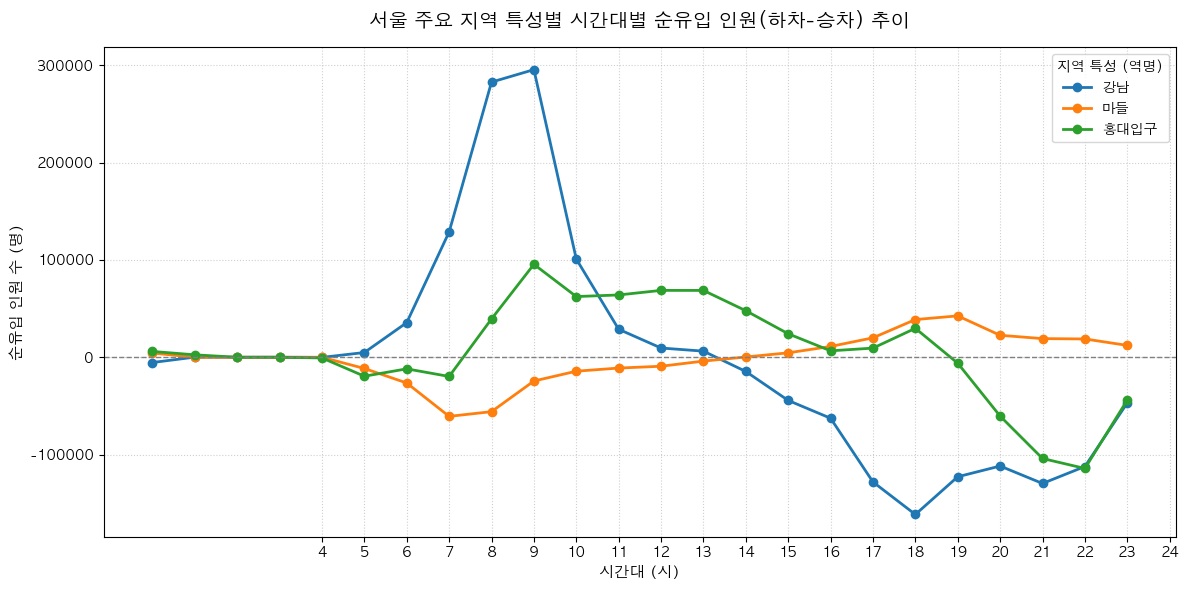

In [21]:
# 자유 분석 — 시각화
plt.figure(figsize=(12, 6))

for station_name in ['강남', '마들', '홍대입구']:
    station_data = df_grouped[df_grouped['station'] == station_name].sort_values('hour')
    plt.plot(station_data['hour'], station_data['net_influx'], marker='o', linewidth=2, label=station_name)

plt.axhline(0, color='gray', linestyle='--', linewidth=1) # 기준선 0 (승하차 균형)
plt.title('서울 주요 지역 특성별 시간대별 순유입 인원(하차-승차) 추이', fontsize=14, pad=15)
plt.xlabel('시간대 (시)', fontsize=11)
plt.ylabel('순유입 인원 수 (명)', fontsize=11)
plt.xticks(range(4, 25)) # 4시부터 24시까지 X축 표시
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='지역 특성 (역명)', fontsize=10)

plt.tight_layout()
plt.show()

**해석:**


---
## Q9. 데이터 저장 — Week 3 시각화 준비 (1점)

**과제:** Week 3에서 활용할 분석 결과를 두 가지 방식으로 저장하세요:

**(1) 전체 데이터 — CSV로 저장 (행 수 많음)**
- `subway_with_transfer.csv` — 환승역 정보가 추가된 long format 데이터 (약 30만 행)

**(2) 분석 결과 요약 — xlsx 단일 파일 multi-sheet 로 저장**

W12 에서 배운 `pd.ExcelWriter` + `with-as` 구문으로 작은 결과들을 한 파일에 묶기:

| sheet 이름 | 내용 |
|---|---|
| `line_summary` | 호선 종합 통계 (약 30행) |
| `station_classification` | 역 분류 (약 500행) |
| `station_hour` | 역 × 시간대 매트릭스 (선택, 큰 편) |

📝 **두 방식을 나누는 이유:**
- xlsx 는 큰 데이터(수십만 행+) 에서 매우 느리고 메모리도 많이 씀
- 분석 결과 요약 (호선·역 단위) 은 작아서 xlsx 가 깔끔하고 검토에도 좋음
- 실제 데이터 엔지니어링에서도 "raw data = CSV/Parquet, 결과 = xlsx" 패턴이 일반적

**파일명:**
- `subway_with_transfer.csv` (큰 데이터)
- `team_B_week2_summary.xlsx` (multi-sheet 분석 결과)

**가이드:**
- xlsx 저장 시 `pd.ExcelWriter` 와 `with` 구문 사용
- 각 데이터프레임은 `to_excel(writer, sheet_name="이름")` 로 저장
- Week 3에서 csv 와 xlsx 모두 불러와서 시각화에 활용


In [22]:
subway.to_csv('subway_with_transfer.csv', index=False, encoding='utf-8-sig')

station_hour_matrix = subway.pivot_table(
    index=['line', 'station'],
    columns='hour',
    values='value',
    aggfunc='mean'
).reset_index()

excel_filename = 'team_B_week2_summary.xlsx'

with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    if 'line_summary_sorted' in locals():
        line_summary_sorted.to_excel(writer, sheet_name='line_summary')
    elif 'line_summary' in locals():
        line_summary.to_excel(writer, sheet_name='line_summary')
        
    if 'station_classification' in locals():
        station_classification.to_excel(writer, sheet_name='station_classification', index=False)
        
    station_hour_matrix.to_excel(writer, sheet_name='station_hour', index=False)

---

## ✅ Week 2 체크리스트

- [ ] 팀 정보 표 갱신
- [ ] Q1: Week 1 결과 정상 로드
- [ ] Q2: 환승역 정보 추가
- [ ] Q3: 호선별 종합 통계
- [ ] Q4: 호선별 핫스팟 Top 3 역
- [ ] Q5: 승차/하차 비대칭 — 주거지/업무지 분류
- [ ] Q6: 환승역 vs 일반역 비교
- [ ] Q7: 가설 종합 검증
- [ ] Q8: **자유 분석 1건** (Week 1과 다른 새 질문)
- [ ] Q9: **CSV 1개 + xlsx multi-sheet 1개** 저장

## 📋 Week 2 제출물
- 이 노트북
- `subway_with_transfer.csv` (raw data)
- `team_B_week2_summary.xlsx` (multi-sheet 분석 결과)

## 🔮 Week 3 미리보기
- seaborn 본격 시각화
- 포스터에 들어갈 핵심 그림 4-5개 선정
- A0 학술 포스터 PDF 제작
